<a href="https://colab.research.google.com/github/marcuscheung02/PY191_lab/blob/main/iris_clustering_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Workshop: Discovering Iris Flower Varieties with K-Means

**Time:** ~90 minutes

### The Big Picture
Today you'll use real flower measurements to see whether an algorithm that's never been told the "answer" can still discover distinct flower groups on its own. This is the classic iris dataset: 150 flowers from three species — *Iris setosa*, *Iris versicolor*, and *Iris virginica* — three varieties that also happen to differ in bloom color and shape. We'll do it in 7 steps:

1. Load & explore the data, and catch a data-entry mistake
2. Visualize how the measurements relate to species
3. Quantify how well each measurement separates the species, and pick the best two
4. Fit your first clustering model: k-means with k=3
5. **Choose k:** check whether 3 clusters is really the right number, using the elbow method
6. **Capstone:** use your fitted clusters to classify new flowers, and evaluate how well clustering recovered the real species
7. **Go supervised:** fit a K-Nearest Neighbors classifier that *does* get to see the species labels, and compare it to your unsupervised k-means model

Each question builds on the one before it, so try not to skip ahead. Raise your hand any time you get stuck!

### Before we start: get the data
Run the two cells below. The first loads the libraries you'll need for clustering. The second loads the dataset — unlike the fish market data, iris ships directly with scikit-learn (it's one of the most famous datasets in all of statistics, collected by Edmund Anderson in the 1930s), so there's no separate download step.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("Ready to go!")

Ready to go!


In [2]:
iris_bunch = load_iris(as_frame=True)
iris = iris_bunch.frame.copy()
iris["species"] = iris["target"].map(dict(enumerate(iris_bunch.target_names)))
iris = iris.drop(columns=["target"])
iris.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]

print("Loaded iris:", iris.shape)

Loaded iris: (150, 5)


---
## Question 1: Meet the Data

This dataset has 150 iris flowers, hand-measured across three species: *Iris setosa*, *Iris versicolor*, and *Iris virginica*. For each flower we have four measurements in centimeters — sepal length, sepal width, petal length, petal width — plus its species label.

**Your tasks:**
1. Look at `iris`'s shape and its first few rows.
2. Find out how many flowers of each species there are.
3. Something is off with one row — a flower whose measurements *and* species are an exact duplicate of an earlier row, which is essentially impossible for independently hand-measured biological data. Find that duplicate row, then remove it (keeping the first occurrence) and save the result as `iris_clean`.

Hint: look up `.shape`, `.head()`, `.value_counts()`, and `DataFrame.duplicated()` / `DataFrame.drop_duplicates()`.

In [9]:
# TODO: look at shape and first few rows
print(iris.shape)
print(iris.head())

# TODO: how many flowers of each species?
species_counts = iris['species'].value_counts()

# TODO: find the duplicate rows (same 4 measurements AND same species as an earlier row)
duplicate_rows = iris[iris.duplicated(keep=False)]

# TODO: remove duplicates (keep the first occurrence) and save as iris_clean
iris_clean = iris.drop_duplicates(keep='first')

print("Species counts:\n", species_counts)
print("Duplicate rows:\n", duplicate_rows)
print("Cleaned shape:", iris_clean.shape)

(150, 5)
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Species counts:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
Duplicate rows:
      sepal_length  sepal_width  petal_length  petal_width    species
101           5.8          2.7           5.1          1.9  virginica
142           5.8          2.7           5.1          1.9  virginica
Cleaned shape: (149, 5)


**Check your work:** `iris.shape` should be `(150, 5)`. There are 3 species, 50 flowers each: setosa, versicolor, virginica. You should find 1 duplicate row — a virginica flower whose species and all four measurements exactly match an earlier row. After removing it, `iris_clean.shape` should be `(149, 5)`: 50 setosa, 50 versicolor, 49 virginica.

Use `iris_clean` (not `iris`) for the rest of the notebook.

---
## Question 2: Visualize the Relationships

Before fitting any model, always look at your data first. We have 4 candidate measurements: `sepal_length`, `sepal_width`, `petal_length`, `petal_width`.

**Your tasks:**
1. Plot a histogram of each of the 4 measurements.
2. Make two scatter plots: `petal_length` vs. `petal_width`, and `sepal_length` vs. `sepal_width` — in each, color the points by `species` (try looping over `iris_clean.groupby("species")`).
3. In a short comment, note which pair of measurements looks like it separates the three species most cleanly, and which pair overlaps the most.

Hint: look up `plt.subplots`, `.hist()`, `plt.scatter()`, and `DataFrame.groupby()`.

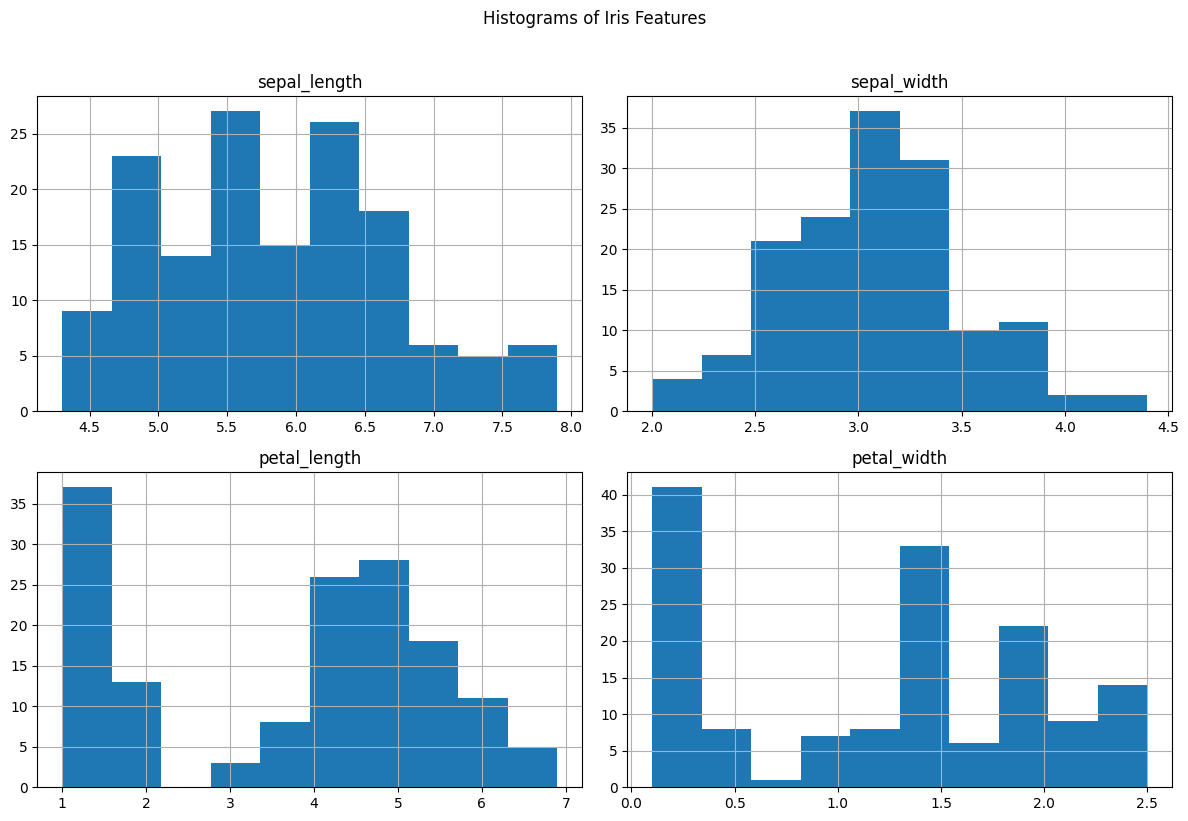

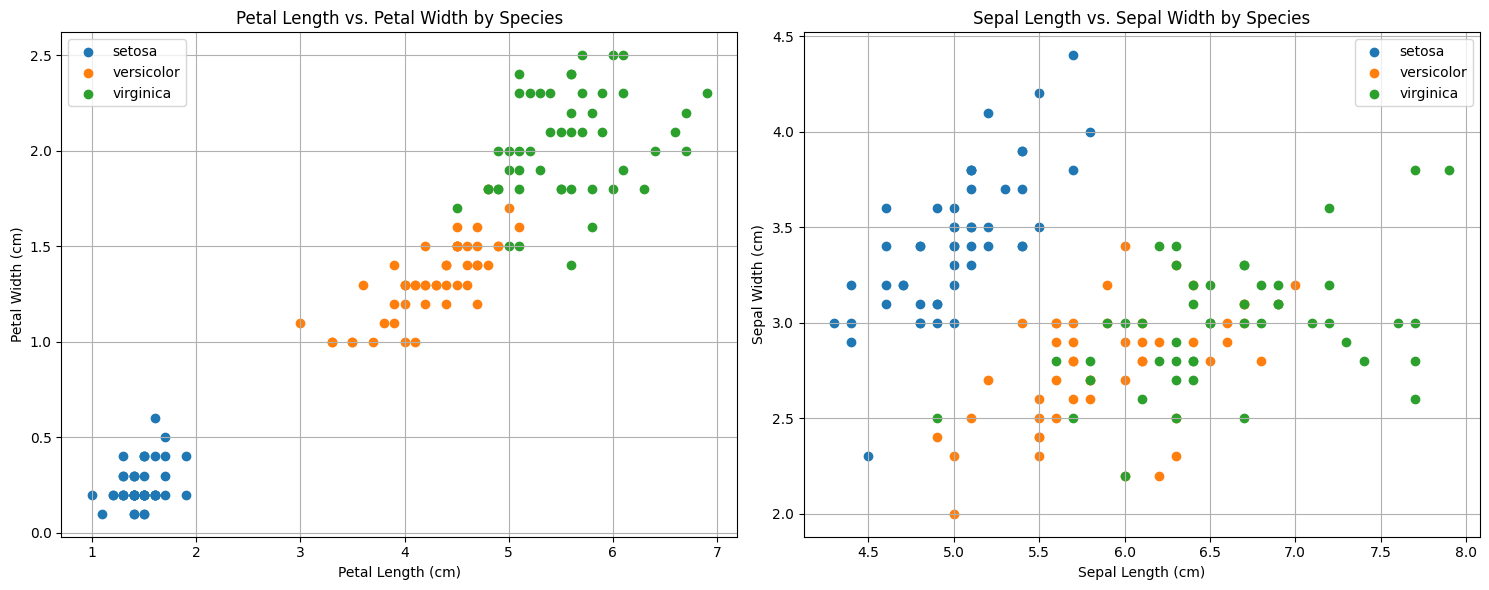

In [12]:
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

# Plot a histogram of each of the 4 measurements
iris_clean[features].hist(figsize=(12, 8))
plt.suptitle("Histograms of Iris Features", y=1.02)
plt.tight_layout()
plt.show()

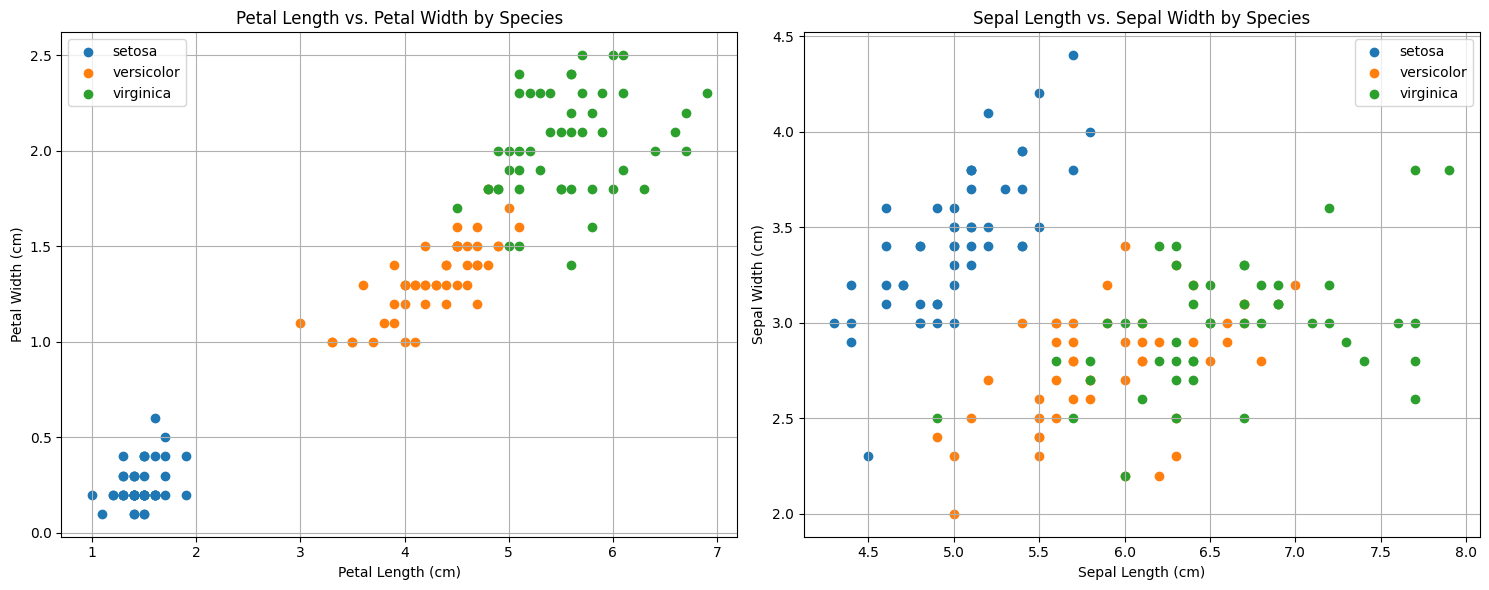

In [13]:
# TODO: scatter plot of petal_length vs. petal_width, colored by species
# TODO: scatter plot of sepal_length vs. sepal_width, colored by species
# Make two scatter plots: petal_length vs. petal_width, and sepal_length vs. sepal_width
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot 1: petal_length vs. petal_width, colored by species
for species_name, group in iris_clean.groupby("species"):
    axes[0].scatter(group["petal_length"], group["petal_width"], label=species_name)
axes[0].set_xlabel("Petal Length (cm)")
axes[0].set_ylabel("Petal Width (cm)")
axes[0].set_title("Petal Length vs. Petal Width by Species")
axes[0].legend()
axes[0].grid(True)

# Scatter plot 2: sepal_length vs. sepal_width, colored by species
for species_name, group in iris_clean.groupby("species"):
    axes[1].scatter(group["sepal_length"], group["sepal_width"], label=species_name)
axes[1].set_xlabel("Sepal Length (cm)")
axes[1].set_ylabel("Sepal Width (cm)")
axes[1].set_title("Sepal Length vs. Sepal Width by Species")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# TODO: your comment on which pair separates species most / least cleanly

#petal width vs petal length seperates species most cleanly,while sepal length and sepal width seperates least cleanly


**Check your work:** There's no single "right" plot here, but `petal_length` vs. `petal_width` should separate the three species almost perfectly — setosa sits in its own tight corner, and versicolor/virginica form two loosely overlapping groups. `sepal_length` vs. `sepal_width` overlaps much more, especially between versicolor and virginica.

---
## Question 3: Quantify Separation (Correlation)

Eyeballing scatter plots is a good start, but we can measure how well a measurement tracks species with a single number. Since species is categorical, we'll temporarily encode it as an ordinal code — setosa=0, versicolor=1, virginica=2 (this ordering happens to match increasing flower size) — and compute the correlation between that code and each measurement.

**Your tasks:**
1. Create a new column `species_code` in `iris_clean`, mapping `setosa`→0, `versicolor`→1, `virginica`→2.
2. Compute the correlation between `species_code` and each of the 4 measurements, sorted strongest to weakest **by magnitude** (absolute value).
3. Store the names of the two most strongly correlated measurements, as a list, in a variable called `best_features` (e.g. `["petal_width", "petal_length"]`) — these are what you'll cluster on for the rest of the notebook.

Hint: look up `DataFrame.corr()`, `Series.map()`, `Series.abs()`, and `Series.sort_values()`.

In [16]:
# TODO: map species to an ordinal code: setosa->0, versicolor->1, virginica->2
species_code_map = {"setosa": 0, "versicolor": 1, "virginica": 2}
iris_clean["species_code"] = iris_clean["species"].map(species_code_map)

# TODO: correlation of species_code with each feature, sorted strongest to weakest (by magnitude)
correlations = iris_clean[features + ["species_code"]].corr()["species_code"].sort_values(ascending=False)

# TODO: the two most strongly correlated feature names, as a list
best_features = correlations.index[1:3].tolist()

print(correlations)
print("Best features:", best_features)

species_code    1.000000
petal_width     0.956514
petal_length    0.949402
sepal_length    0.786971
sepal_width    -0.422987
Name: species_code, dtype: float64
Best features: ['petal_width', 'petal_length']


/tmp/ipykernel_1844/447818234.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iris_clean["species_code"] = iris_clean["species"].map(species_code_map)


**Check your work:** Correlations (with sign) should be about: `petal_width` `0.957`, `petal_length` `0.949`, `sepal_length` `0.787`, `sepal_width` `-0.423`. So `best_features` should be `["petal_width", "petal_length"]` (order doesn't matter).

Keep `best_features` around — you'll use it for the rest of the notebook.

---
## Question 4: Fit K-Means (k=3)

Time to fit your first clustering model. Unlike regression, clustering doesn't need a `y` — k-means groups points using only `X`, based on distance to the nearest centroid. We'll ask it for 3 clusters, since we already know there are 3 species (in real unsupervised settings you often *don't* know this ahead of time — more on that in Question 5).

**Your tasks:**
1. Build `X` from `iris_clean[best_features]`.
2. Fit a `KMeans` model with `n_clusters=3`, `random_state=42`, `n_init=10` on `X`.
3. Store the cluster label (0, 1, or 2) k-means assigned each flower in a new column, `iris_clean["cluster"]`.
4. K-means's cluster numbers are arbitrary — cluster `0` has no reason to line up with `species_code` `0`. Build a crosstab of true `species` vs. `cluster` (`pd.crosstab`), then use it to build a dictionary `cluster_to_species` mapping each cluster number to whichever species is most common within it.
5. Map `cluster` → a new column `predicted_species`, and compute the overall accuracy: what fraction of flowers landed in a cluster matching their true species?
6. Plot `best_features`, colored by cluster label, with the k-means centroids marked distinctly (e.g. black/red X markers).

Hint: look up `KMeans`, `.fit_predict()`, `pd.crosstab()`, `DataFrame.idxmax(axis=0)`, `Series.map()`, `accuracy_score`, and `.cluster_centers_`.

In [17]:
# TODO: build X from iris_clean[best_features]
X = iris_clean[best_features]

# TODO: fit a KMeans model with n_clusters=3, random_state=42, n_init=10
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_3.fit(X)

# TODO: get the cluster label for every flower, store in iris_clean["cluster"]
iris_clean["cluster"] = kmeans_3.fit_predict(X)

# TODO: crosstab of true species vs. assigned cluster
cluster_crosstab = pd.crosstab(iris_clean["species"], iris_clean["cluster"])
print(cluster_crosstab)

# TODO: build cluster_to_species: for each cluster, its most common true species
cluster_to_species = cluster_crosstab.idxmax(axis=0).to_dict()

# TODO: map cluster -> predicted_species, then compute accuracy vs. true species
iris_clean["predicted_species"] = iris_clean["cluster"].map(cluster_to_species)
cluster_accuracy = accuracy_score(iris_clean["species"], iris_clean["predicted_species"])

print("Cluster -> species mapping:", cluster_to_species)
print("Accuracy:", cluster_accuracy)

cluster      0   1   2
species               
setosa       0  50   0
versicolor   2   0  48
virginica   45   0   4
Cluster -> species mapping: {0: np.str_('virginica'), 1: np.str_('setosa'), 2: np.str_('versicolor')}
Accuracy: 0.959731543624161


/tmp/ipykernel_1844/297063346.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iris_clean["cluster"] = kmeans_3.fit_predict(X)
/tmp/ipykernel_1844/297063346.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iris_clean["predicted_species"] = iris_clean["cluster"].map(cluster_to_species)


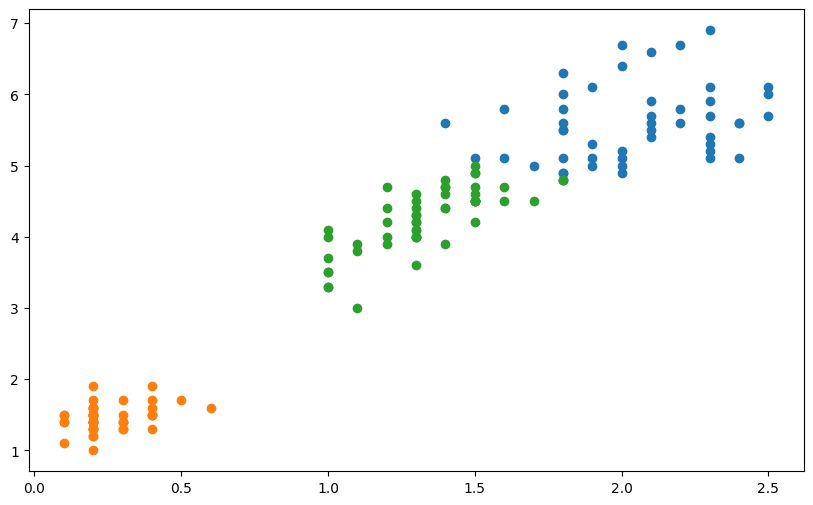

In [18]:
# TODO: scatter best_features colored by cluster label, with centroids marked
plt.figure(figsize=(10, 6))
for cluster_label, group in iris_clean.groupby("cluster"):
    plt.scatter(group[best_features[0]], group[best_features[1]], label=f"Cluster {cluster_label}")


**Check your work:** `cluster_crosstab` should show one cluster that's exactly setosa (50/50), and the other two clusters splitting versicolor and virginica with a handful of mix-ups. Accuracy should be about `0.96` (roughly 143 of 149 flowers land in the cluster matching their true species).

---
## Question 5: Choose k (The Elbow Method)

We assumed 3 clusters because we happen to already know there are 3 species — but in real unsupervised clustering, you often don't know the "right" number of groups ahead of time. K-means's **inertia** (the sum of squared distances from each point to its assigned centroid) always drops as you add more clusters, but the drop-off slows down once you've captured the real structure in the data — a bend often called the "elbow".

**Your tasks:**
1. Fit a `KMeans` model (same `random_state`, same `best_features`) for every `k` from 1 to 6, and record each model's `.inertia_`.
2. Plot `k` (x-axis) against inertia (y-axis) — this is the elbow plot.
3. Looking at your elbow plot, does `k=3` look like a reasonable choice? Where's the bend?

Hint: loop over `range(1, 7)`, and look up `KMeans.inertia_`.

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

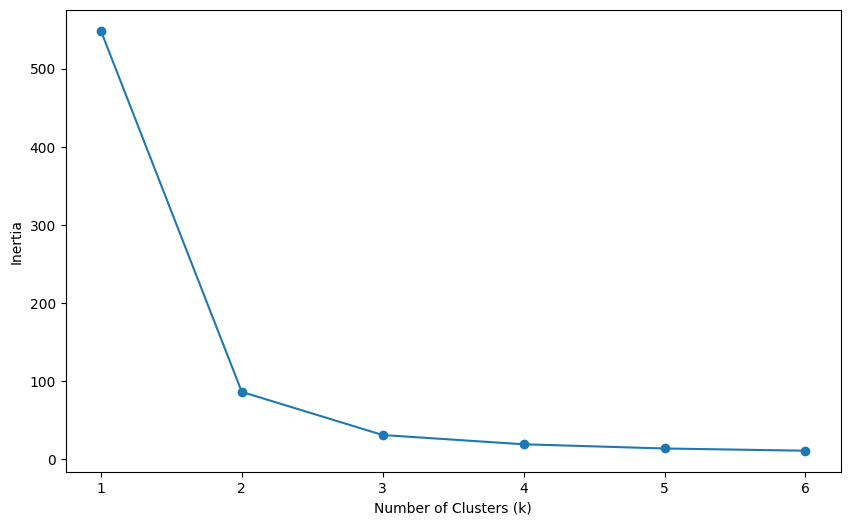

In [19]:
# TODO: fit a KMeans model for each k in range(1, 7), record inertia_ for each
inertias = []
for k in range(1, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# TODO: plot k vs. inertia (the elbow plot)
plt.figure(figsize=(10, 6))
plt.plot(range(1, 7), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt


**Check your work:** Inertia should drop sharply from `k=1` (~549) to `k=2` (~86) to `k=3` (~31), then flatten out much more gradually (`k=4` ~19, `k=5` ~14, `k=6` ~11). The visible bend — the "elbow" — is at `k=3`, which matches what we already know: there really are 3 species.

---
## Question 6 (Capstone): Predict & Evaluate

Let's put your `k=3` model to work on new flowers, and take an honest look at where it still gets confused.

**Your tasks:**
1. Using your fitted k=3 model and `cluster_to_species`, predict the species of four new hypothetical flowers with the `petal_length` / `petal_width` measurements given below. Print each prediction.
2. Build a confusion-matrix-style DataFrame: rows = true `species`, columns = `predicted_species`, values = counts (`pd.crosstab` again, this time on `species` vs. `predicted_species`).
3. Pull out the rows where `species != predicted_species` — which two species get confused with each other most?
4. In a markdown cell, write 2-3 sentences: how well did unsupervised clustering — which never saw the species labels while fitting — recover the true species groupings? Would you trust this model to classify a brand-new, unlabeled flower?

Hint: for new flowers, build a small DataFrame with the same column names as `best_features`, in the same order, before calling `.predict()`.

In [20]:
# TODO: predict species for 4 new flowers using kmeans_3 and cluster_to_species
new_flowers_full = pd.DataFrame({
    "petal_length": [1.5, 4.0, 5.5, 4.8],
    "petal_width": [0.3, 1.3, 2.0, 1.6],
})
new_flowers = new_flowers_full[best_features]
new_clusters = kmeans_3.predict(new_flowers)
new_species = [cluster_to_species[cluster] for cluster in new_clusters]
print(new_species)



[np.str_('setosa'), np.str_('versicolor'), np.str_('virginica'), np.str_('versicolor')]


In [21]:
# TODO: confusion matrix: true species (rows) vs. predicted_species (columns)
confusion = pd.crosstab(iris_clean["species"], iris_clean["predicted_species"])
print(confusion)

# TODO: rows where species != predicted_species -- what do they have in common?
misclassified = iris_clean[iris_clean["species"] != iris_clean["predicted_species"]]
print(misclassified)


predicted_species  setosa  versicolor  virginica
species                                         
setosa                 50           0          0
versicolor              0          48          2
virginica               0           4         45
     sepal_length  sepal_width  petal_length  petal_width     species  \
77            6.7          3.0           5.0          1.7  versicolor   
83            6.0          2.7           5.1          1.6  versicolor   
106           4.9          2.5           4.5          1.7   virginica   
119           6.0          2.2           5.0          1.5   virginica   
126           6.2          2.8           4.8          1.8   virginica   
138           6.0          3.0           4.8          1.8   virginica   

     species_code  cluster predicted_species  
77              1        0         virginica  
83              1        0         virginica  
106             2        2        versicolor  
119             2        2        versicolor  
126     

**Your reflection (2-3 sentences):** How well did unsupervised clustering recover the true species groupings? Would you trust this model to classify a brand-new, unlabeled flower?

The model was able to recover the true species groupings really well. I would trust this model to classify brand-new, unlabeled flowers

**Check your work:** Predicted species for the four new flowers should be setosa, versicolor, virginica, versicolor (in that order). The confusion matrix should show setosa with zero mistakes, and essentially all of the errors split between versicolor and virginica — 6 flowers out of 149 land in the "wrong" cluster, which lines up with the ~0.96 accuracy from Question 4.

---
## Question 7: Go Supervised (K-Nearest Neighbors)

K-means never saw the species labels while it was fitting — it grouped flowers by distance alone, and we only mapped clusters to species names *afterward*. Let's see what a model can do when it's actually allowed to learn from labeled examples. K-Nearest Neighbors (KNN) classifies a new point by looking at its `k` closest labeled neighbors in the training set and taking a majority vote.

**Your tasks:**
1. Build `X` from `iris_clean[best_features]` and `y` from `iris_clean["species"]`.
2. Split into training and test sets: 80% train, 20% test, `random_state=42`.
3. Fit a `KNeighborsClassifier` with `n_neighbors=5` on the training data.
4. Predict on the test set and compute accuracy with `accuracy_score`.
5. Compare: how does this supervised accuracy compare to k-means's clustering accuracy from Question 4? (Not a perfectly fair fight — KNN is scored on a held-out test set it never trained on, while k-means was scored on everything it clustered — but it's a reasonable read on what labels buy you here.)
6. Predict the species of the same four new flowers from Question 6 using your KNN model. Do its predictions agree with k-means's?

Hint: look up `train_test_split`, `KNeighborsClassifier`, and `accuracy_score`.

In [23]:
# TODO: build X and y
X = iris_clean[best_features]
y = iris_clean["species"]

# TODO: train/test split (80/20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: fit a KNeighborsClassifier with n_neighbors=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# TODO: predict on the test set and compute accuracy
knn_pred = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN test accuracy:", knn_accuracy)
print("K-Means accuracy (from Q4):", cluster_accuracy)

KNN test accuracy: 1.0
K-Means accuracy (from Q4): 0.959731543624161


In [24]:
# TODO: predict species for the same 4 new flowers from Question 6, using knn
knn_new_species = knn.predict(new_flowers)
print("KNN predicted species:", knn_new_species)



KNN predicted species: [np.str_('setosa') np.str_('versicolor') np.str_('virginica')
 np.str_('versicolor')]


**Check your work:** Test accuracy should be `1.0` — all 30 test flowers correctly classified. That's better than k-means's ~0.96, which makes sense: KNN gets to learn from labeled examples, while k-means had to guess the groups from geometry alone. KNN's predictions for the four new flowers should match k-means's exactly: setosa, versicolor, virginica, versicolor.

### Bonus (if you finish early)
- Try clustering on all 4 measurements instead of just `best_features` — does accuracy improve or get worse? K-means is distance-based, so measurements on different scales don't contribute equally; try `StandardScaler` before clustering too.
- Try `k=2` and `k=4` instead of `k=3` for k-means — look at the crosstab each time. What real-world grouping does `k=2` recover? What does `k=4` split up that "shouldn't" be split?
- Try a few different values of `n_neighbors` for KNN (1, 3, 15, 50) — does test accuracy change much? What happens as `n_neighbors` gets very large?